In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("final_mood_dataset.csv")

print(data.head())

   cadence  stride_time_mean  stride_time_std  mean_pressure_left  \
0    105.0            0.5900         0.118181         1302.483125   
1     90.0            0.7140         0.152132         1307.715312   
2     75.0            0.8375         0.126170         1488.584687   
3     90.0            0.5740         0.092217         1459.884687   
4     90.0            0.6960         0.258967         1342.573125   

   mean_pressure_right  peak_pressure_left  peak_pressure_right  \
0          1104.375937              4075.0               4095.0   
1          1109.493438              4075.0               4055.0   
2           996.670313              4049.0               4077.0   
3          1010.381562              4054.0               4095.0   
4          1113.518437              4054.0               4095.0   

   pressure_variance_left  pressure_variance_right  heel_to_toe_ratio_left  \
0            2.546390e+06             2.012132e+06                0.944378   
1            2.442844e+06 

In [3]:
X = data.drop("mood", axis=1)
y = data["mood"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 616
Testing samples: 154


In [5]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred = model.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.987012987012987


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       1.00      0.96      0.98        57
       happy       0.96      1.00      0.98        47
         sad       1.00      1.00      1.00        50

    accuracy                           0.99       154
   macro avg       0.99      0.99      0.99       154
weighted avg       0.99      0.99      0.99       154



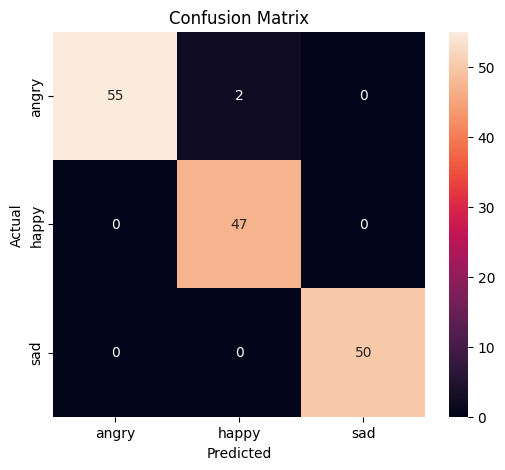

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
importances = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
})

importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df.head(10))

                    feature  importance
18        imu_acc_std_right    0.248317
17         imu_acc_std_left    0.197096
22       imu_gyro_std_right    0.164883
21        imu_gyro_std_left    0.159845
15        imu_acc_mean_left    0.051772
8   pressure_variance_right    0.037690
13        impact_force_left    0.031438
11        contact_area_left    0.021889
5        peak_pressure_left    0.021187
3        mean_pressure_left    0.019936


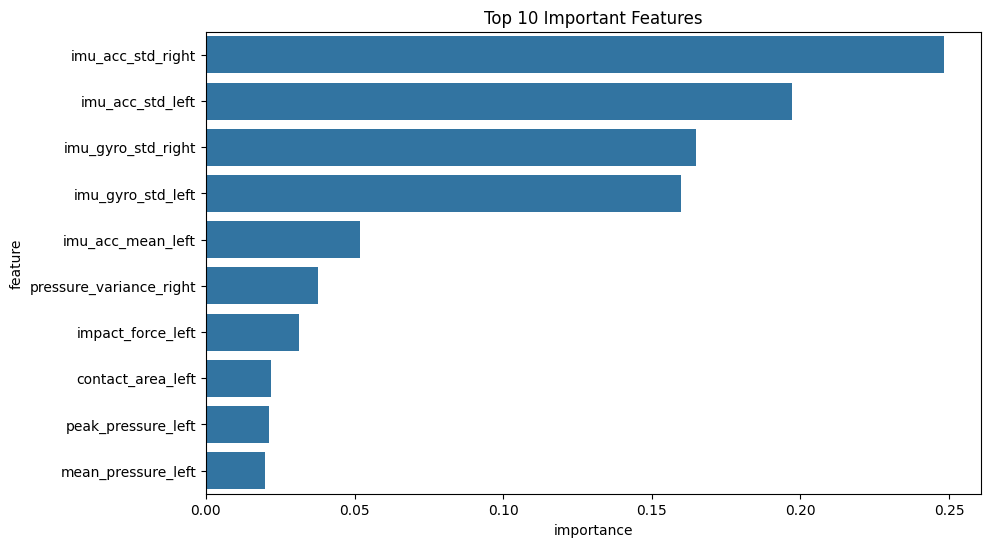

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [12]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Mood:", prediction[0])

Predicted Mood: angry


In [13]:
import joblib

joblib.dump(model, "mood_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']